# 01 v2 — Prepare Feature Datasets (from cached POC data)

Identical outputs to `01_prepare_data.ipynb` but reads pre-fetched data from
`transformation_poc/` instead of querying the ESA Gaia archive.

**Source data** (from POC):
- `xpcoeff_110d_L2.csv` — L2-normalised 110-d XP coefficients (source_id, y, bp_00…rp_54)
- `xp_sampled_spectra.csv` — calibrated sampled spectra (source_id, y, wl_336…wl_1020)

**Outputs** (to `data/`):
- `og_xp.csv` — baseline L2-normalised XP coefficients
- `{basis}_{n}_raw.csv` / `{basis}_{n}_L2.csv` — polynomial features (4 bases × 5 dims)
- `{basis}_{n}_L2.csv` — additional Chebyshev/Legendre L2 features at n=5,15,25,35,45 (focused experiment)
- `splits.json` — 10 stratified 80/20 train/test splits (original experiment)
- `splits_rskf.json` — 10×5 Repeated Stratified K-Fold splits (focused experiment)

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from clustertools.spectra.xp import l2_normalize
from clustertools.spectra.polynomial import fit_polynomial, POLY_CLASSES
from sklearn.model_selection import StratifiedShuffleSplit, RepeatedStratifiedKFold

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# ── Configuration ──
EXPERIMENT_DIR = Path.cwd() if Path("data").exists() else Path("transformation_experiment")
POC_DIR = Path("transformation_poc") if Path("transformation_poc").exists() else Path("..") / "transformation_poc"
DATA_OUT = EXPERIMENT_DIR / "data"
DATA_OUT.mkdir(exist_ok=True)

N_COEFFS_LIST = [10, 20, 30, 40, 50]
N_SPLITS = 10
TEST_SIZE = 0.20

print("Experiment dir:", EXPERIMENT_DIR.resolve())
print("POC dir:       ", POC_DIR.resolve())
print("Output dir:    ", DATA_OUT.resolve())

Experiment dir: /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment
POC dir:        /Users/erikak/Documents/uni/bakalauras/kodas/transformation_poc
Output dir:     /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/data


## 1. Baseline OG XP coefficients

Load L2-normalised 110-d coefficients that were pre-fetched and parsed in the POC.
This replaces the Gaia TAP fetch → parse → L2-normalise pipeline.

In [3]:
df_og = pd.read_csv(POC_DIR / "xpcoeff_110d_L2.csv")

feat_cols = [c for c in df_og.columns if c not in ("source_id", "y")]
print(f"OG XP with labels: {df_og.shape[0]} stars, {len(feat_cols)} features")
print(f"Class balance: {dict(df_og['y'].value_counts().sort_index())}")

og_out = DATA_OUT / "og_xp.csv"
df_og.to_csv(og_out, index=False)
print(f"\nSaved baseline: {og_out.name}")

OG XP with labels: 2815 stars, 110 features
Class balance: {0: np.int64(2257), 1: np.int64(558)}

Saved baseline: og_xp.csv


## 2. Load sampled spectra for polynomial fitting

Pre-calibrated spectra from `gaiaxpy.calibrate` (336–1020 nm, 2 nm steps).

In [4]:
df_spectra = pd.read_csv(POC_DIR / "xp_sampled_spectra.csv")

wl_cols = [c for c in df_spectra.columns if c.startswith("wl_")]
wavelengths = np.array([float(c.split("_")[1]) for c in wl_cols])
spectra_source_ids = df_spectra["source_id"].values
spectra_labels = df_spectra["y"].values
spectra_matrix = df_spectra[wl_cols].to_numpy(dtype=np.float64)

print(f"Sampled spectra: {spectra_matrix.shape[0]} stars, {spectra_matrix.shape[1]} wavelength bins")
print(f"Wavelength range: {wavelengths[0]:.0f} – {wavelengths[-1]:.0f} nm")

Sampled spectra: 2815 stars, 343 wavelength bins
Wavelength range: 336 – 1020 nm


## 3. Generate polynomial features

For each (basis, n_coeffs), fit an orthogonal polynomial to each star's
spectrum and save **raw** and **L2-normalised** variants.

In [5]:
BASIS_MAP = {
    "Chebyshev": "chebyshev",
    "Hermite":   "hermite",
    "Laguerre":  "laguerre",
    "Legendre":  "legendre",
}


def fit_all_stars(wavelengths, spectra_matrix, basis_name, n_coeffs):
    """Fit polynomial to every star."""
    n_stars = spectra_matrix.shape[0]
    coeff_matrix = np.zeros((n_stars, n_coeffs), dtype=np.float64)
    r2_values = np.zeros(n_stars, dtype=np.float64)

    for i in range(n_stars):
        result = fit_polynomial(
            wavelengths, spectra_matrix[i],
            basis=basis_name, n_coeffs=n_coeffs,
        )
        coeff_matrix[i] = result["coefficients"][:n_coeffs]
        r2_values[i] = result["metrics"]["R2"]

    return coeff_matrix, r2_values


def build_feature_df(source_ids, labels, coeff_matrix, n_coeffs):
    """Assemble a feature DataFrame with source_id, y, and coefficient columns."""
    col_names = [f"c{i:03d}" for i in range(n_coeffs)]
    df = pd.DataFrame(coeff_matrix, columns=col_names)
    df.insert(0, "y", labels)
    df.insert(0, "source_id", source_ids)
    return df

In [6]:
reconstruction_quality = []

for basis_name, file_prefix in BASIS_MAP.items():
    for n_coeffs in N_COEFFS_LIST:
        print(f"  {file_prefix:10s} n={n_coeffs:3d} ... ", end="", flush=True)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            coeff_raw, r2_values = fit_all_stars(
                wavelengths, spectra_matrix, basis_name, n_coeffs,
            )

        median_r2 = np.median(r2_values)
        reconstruction_quality.append({
            "basis": file_prefix, "n_coeffs": n_coeffs,
            "median_r2": median_r2, "min_r2": np.min(r2_values),
        })

        df_feat_raw = build_feature_df(spectra_source_ids, spectra_labels, coeff_raw, n_coeffs)

        coeff_cols = [f"c{i:03d}" for i in range(n_coeffs)]
        df_feat_l2 = l2_normalize(df_feat_raw, coeff_cols=coeff_cols)

        raw_path = DATA_OUT / f"{file_prefix}_{n_coeffs}_raw.csv"
        l2_path  = DATA_OUT / f"{file_prefix}_{n_coeffs}_L2.csv"
        df_feat_raw.to_csv(raw_path, index=False)
        df_feat_l2.to_csv(l2_path, index=False)

        print(f"R²={median_r2:.6f}  → {raw_path.name}, {l2_path.name}")

print("\nDone. All polynomial features saved (raw + L2 variants).")

  chebyshev  n= 10 ... R²=0.995774  → chebyshev_10_raw.csv, chebyshev_10_L2.csv
  chebyshev  n= 20 ... R²=0.996921  → chebyshev_20_raw.csv, chebyshev_20_L2.csv
  chebyshev  n= 30 ... R²=0.997409  → chebyshev_30_raw.csv, chebyshev_30_L2.csv
  chebyshev  n= 40 ... R²=0.997794  → chebyshev_40_raw.csv, chebyshev_40_L2.csv
  chebyshev  n= 50 ... R²=0.998071  → chebyshev_50_raw.csv, chebyshev_50_L2.csv
  hermite    n= 10 ... R²=0.995774  → hermite_10_raw.csv, hermite_10_L2.csv
  hermite    n= 20 ... R²=0.996813  → hermite_20_raw.csv, hermite_20_L2.csv
  hermite    n= 30 ... R²=0.996851  → hermite_30_raw.csv, hermite_30_L2.csv
  hermite    n= 40 ... R²=0.996920  → hermite_40_raw.csv, hermite_40_L2.csv
  hermite    n= 50 ... R²=0.996955  → hermite_50_raw.csv, hermite_50_L2.csv
  laguerre   n= 10 ... R²=0.995391  → laguerre_10_raw.csv, laguerre_10_L2.csv
  laguerre   n= 20 ... R²=0.996312  → laguerre_20_raw.csv, laguerre_20_L2.csv
  laguerre   n= 30 ... R²=0.996547  → laguerre_30_raw.csv, lague

## 3b. Additional dimensions for focused experiment

Generate Chebyshev and Legendre L2 features at **n = [5, 15, 25, 35, 45]** to
complement the existing [10, 20, 30, 40, 50] grid. This creates a uniform step-5
grid for smooth efficiency curves. Only L2 variants are needed (L2 consistently
outperformed raw in the initial experiment).

In [7]:
FOCUSED_BASES = {"chebyshev": "chebyshev", "legendre": "legendre"}
EXTRA_N_COEFFS = [5, 15, 25, 35, 45]

extra_quality = []

for file_prefix, basis_name in FOCUSED_BASES.items():
    for n_coeffs in EXTRA_N_COEFFS:
        l2_path = DATA_OUT / f"{file_prefix}_{n_coeffs}_L2.csv"
        if l2_path.exists():
            print(f"  {file_prefix:10s} n={n_coeffs:3d} — already exists, skipping")
            continue

        print(f"  {file_prefix:10s} n={n_coeffs:3d} ... ", end="", flush=True)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            coeff_raw, r2_values = fit_all_stars(
                wavelengths, spectra_matrix, basis_name.capitalize(), n_coeffs,
            )

        median_r2 = np.median(r2_values)
        extra_quality.append({
            "basis": file_prefix, "n_coeffs": n_coeffs,
            "median_r2": median_r2, "min_r2": np.min(r2_values),
        })

        df_feat_raw = build_feature_df(spectra_source_ids, spectra_labels, coeff_raw, n_coeffs)
        coeff_cols = [f"c{i:03d}" for i in range(n_coeffs)]
        df_feat_l2 = l2_normalize(df_feat_raw, coeff_cols=coeff_cols)
        df_feat_l2.to_csv(l2_path, index=False)

        print(f"R²={median_r2:.6f}  → {l2_path.name}")

if extra_quality:
    print(f"\nGenerated {len(extra_quality)} new feature files.")
    df_eq = pd.DataFrame(extra_quality)
    print(df_eq.to_string(index=False))
else:
    print("\nAll focused-experiment feature files already exist.")

  chebyshev  n=  5 ... R²=0.994399  → chebyshev_5_L2.csv
  chebyshev  n= 15 ... R²=0.996701  → chebyshev_15_L2.csv
  chebyshev  n= 25 ... R²=0.997188  → chebyshev_25_L2.csv
  chebyshev  n= 35 ... R²=0.997573  → chebyshev_35_L2.csv
  chebyshev  n= 45 ... R²=0.997974  → chebyshev_45_L2.csv
  legendre   n=  5 ... R²=0.994399  → legendre_5_L2.csv
  legendre   n= 15 ... R²=0.996701  → legendre_15_L2.csv
  legendre   n= 25 ... R²=0.997188  → legendre_25_L2.csv
  legendre   n= 35 ... R²=0.997573  → legendre_35_L2.csv
  legendre   n= 45 ... R²=0.997974  → legendre_45_L2.csv

Generated 10 new feature files.
    basis  n_coeffs  median_r2   min_r2
chebyshev         5   0.994399 0.894827
chebyshev        15   0.996701 0.925918
chebyshev        25   0.997188 0.933162
chebyshev        35   0.997573 0.939157
chebyshev        45   0.997974 0.942554
 legendre         5   0.994399 0.894827
 legendre        15   0.996701 0.925918
 legendre        25   0.997188 0.933162
 legendre        35   0.997573 0.9

## 4. Reconstruction quality summary

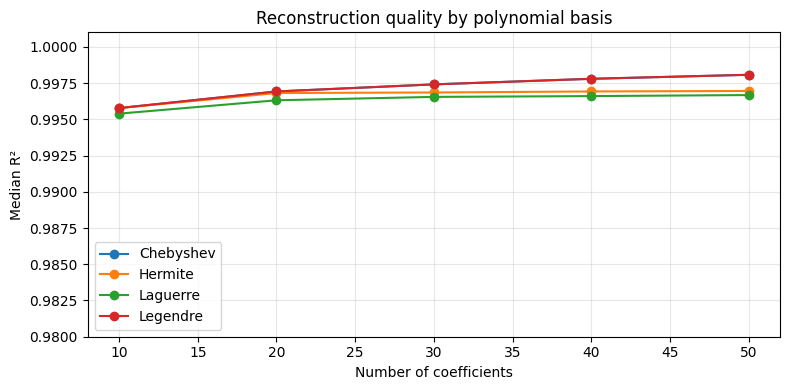

basis,chebyshev,hermite,laguerre,legendre
n_coeffs,,,,
10,0.995774,0.995774,0.995391,0.995774
20,0.996921,0.996813,0.996312,0.996921
30,0.997409,0.996851,0.996547,0.997409
40,0.997794,0.996920,0.996601,0.997794
50,0.998071,0.996955,0.996673,0.998071


In [8]:
df_quality = pd.DataFrame(reconstruction_quality)

fig, ax = plt.subplots(figsize=(8, 4))
for basis in BASIS_MAP.values():
    subset = df_quality[df_quality["basis"] == basis]
    ax.plot(subset["n_coeffs"], subset["median_r2"], "o-", label=basis.capitalize())
ax.set_xlabel("Number of coefficients")
ax.set_ylabel("Median R²")
ax.set_title("Reconstruction quality by polynomial basis")
ax.legend()
ax.set_ylim(0.98, 1.001)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df_quality.pivot(index="n_coeffs", columns="basis", values="median_r2").round(6)

## 5. Generate reproducible train/test splits

10 stratified 80/20 splits (Wilcoxon signed-rank minimum p ≈ 0.002).

In [9]:
og_labels = df_og["y"].values

splits = {}
sss = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, random_state=RANDOM_STATE)

for i, (train_idx, test_idx) in enumerate(sss.split(np.zeros(len(og_labels)), og_labels)):
    splits[f"seed_{i}"] = {
        "train": train_idx.tolist(),
        "test":  test_idx.tolist(),
    }
    n_pos_tr = og_labels[train_idx].sum()
    n_pos_te = og_labels[test_idx].sum()
    print(f"Split {i}: train={len(train_idx)} (pos={n_pos_tr}), test={len(test_idx)} (pos={n_pos_te})")

splits_path = DATA_OUT / "splits.json"
with open(splits_path, "w") as f:
    json.dump(splits, f, indent=2)

print(f"\nSaved {N_SPLITS} splits → {splits_path.name}")

Split 0: train=2252 (pos=446), test=563 (pos=112)
Split 1: train=2252 (pos=446), test=563 (pos=112)
Split 2: train=2252 (pos=446), test=563 (pos=112)
Split 3: train=2252 (pos=446), test=563 (pos=112)
Split 4: train=2252 (pos=446), test=563 (pos=112)
Split 5: train=2252 (pos=446), test=563 (pos=112)
Split 6: train=2252 (pos=446), test=563 (pos=112)
Split 7: train=2252 (pos=446), test=563 (pos=112)
Split 8: train=2252 (pos=446), test=563 (pos=112)
Split 9: train=2252 (pos=446), test=563 (pos=112)

Saved 10 splits → splits.json


## 5b. Repeated Stratified K-Fold splits (focused experiment)

10 repeats × 5 folds for proper statistical testing. Within each repeat every star
appears in the test set exactly once. Repeat-level aggregation gives 10 quasi-independent
scores for Wilcoxon signed-rank tests.

In [10]:
N_REPEATS = 10
N_FOLDS = 5

rskf = RepeatedStratifiedKFold(
    n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=RANDOM_STATE,
)

splits_rskf = {}
for i, (train_idx, test_idx) in enumerate(rskf.split(np.zeros(len(og_labels)), og_labels)):
    rep = i // N_FOLDS
    fold = i % N_FOLDS
    key = f"rep{rep}_fold{fold}"
    splits_rskf[key] = {
        "train": train_idx.tolist(),
        "test":  test_idx.tolist(),
    }

rskf_path = DATA_OUT / "splits_rskf.json"
with open(rskf_path, "w") as f:
    json.dump(splits_rskf, f, indent=2)

print(f"Saved {len(splits_rskf)} splits ({N_REPEATS} repeats × {N_FOLDS} folds) → {rskf_path.name}")
print(f"Train/test sizes: {len(splits_rskf['rep0_fold0']['train'])} / {len(splits_rskf['rep0_fold0']['test'])}")

for rep in range(min(3, N_REPEATS)):
    for fold in range(N_FOLDS):
        key = f"rep{rep}_fold{fold}"
        te = np.array(splits_rskf[key]["test"])
        n_pos = og_labels[te].sum()
        print(f"  {key}: test={len(te)} (pos={n_pos})")
print("  ...")

Saved 50 splits (10 repeats × 5 folds) → splits_rskf.json
Train/test sizes: 2252 / 563
  rep0_fold0: test=563 (pos=111)
  rep0_fold1: test=563 (pos=111)
  rep0_fold2: test=563 (pos=112)
  rep0_fold3: test=563 (pos=112)
  rep0_fold4: test=563 (pos=112)
  rep1_fold0: test=563 (pos=111)
  rep1_fold1: test=563 (pos=111)
  rep1_fold2: test=563 (pos=112)
  rep1_fold3: test=563 (pos=112)
  rep1_fold4: test=563 (pos=112)
  rep2_fold0: test=563 (pos=111)
  rep2_fold1: test=563 (pos=111)
  rep2_fold2: test=563 (pos=112)
  rep2_fold3: test=563 (pos=112)
  rep2_fold4: test=563 (pos=112)
  ...


In [11]:
print("\nFiles in data/:")
for p in sorted(DATA_OUT.glob("*")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:30s}  {size_kb:8.1f} KB")


Files in data/:
  chebyshev_10.csv                   688.9 KB
  chebyshev_10_L2.csv                631.8 KB
  chebyshev_10_raw.csv               689.5 KB
  chebyshev_15_L2.csv                928.1 KB
  chebyshev_20.csv                  1315.3 KB
  chebyshev_20_L2.csv               1226.5 KB
  chebyshev_20_raw.csv              1316.3 KB
  chebyshev_25_L2.csv               1526.4 KB
  chebyshev_30.csv                  1943.5 KB
  chebyshev_30_L2.csv               1825.4 KB
  chebyshev_30_raw.csv              1944.8 KB
  chebyshev_35_L2.csv               2124.8 KB
  chebyshev_40.csv                  2570.9 KB
  chebyshev_40_L2.csv               2425.7 KB
  chebyshev_40_raw.csv              2572.5 KB
  chebyshev_45_L2.csv               2726.8 KB
  chebyshev_50.csv                  3200.1 KB
  chebyshev_50_L2.csv               3027.6 KB
  chebyshev_50_raw.csv              3201.9 KB
  chebyshev_5_L2.csv                 334.5 KB
  hermite_10.csv                     635.8 KB
  hermite_10_L2.c